# Week 4: Cats vs Dogs Classification using Transfer Learning

## Project Overview

This project uses Transfer Learning with MobileNetV2, a pretrained convolutional neural network trained on the ImageNet dataset, to classify images of cats and dogs.

## Objectives

* Load and preprocess the Cats vs Dogs dataset from TensorFlow Datasets.
* Apply data augmentation to improve model generalization.
* Use MobileNetV2 as a frozen feature extractor.
* Train a custom classification head for binary image classification.
* Achieve more than 95% validation accuracy.
* Save the trained model weights for future fine-tuning.

## Model Architecture

Input Image (160 × 160 × 3)
→ Data Augmentation (RandomFlip, RandomRotation)
→ MobileNetV2 Preprocessing
→ MobileNetV2 (Frozen)
→ GlobalAveragePooling2D
→ Dropout (0.2)
→ Dense (1, Sigmoid)
→ Cat / Dog Prediction

## Technologies Used

* Python
* TensorFlow
* TensorFlow Datasets (TFDS)
* MobileNetV2
* Google Colab / Jupyter Notebook
* Matplotlib

## Expected Outcome

Train a high-accuracy image classifier using transfer learning and demonstrate the effectiveness of pretrained deep learning models for computer vision tasks.


Import Libraries

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

Check GPU:

In [ ]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load Cats vs Dogs Dataset

In [ ]:
(train_ds, val_ds), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

print(info)

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

Resize Images

MobileNetV2 expects fixed-size images.

In [ ]:
IMG_SIZE = (160, 160)

train_ds = train_ds.map(
    lambda x, y: (tf.image.resize(x, IMG_SIZE), y)
)

val_ds = val_ds.map(
    lambda x, y: (tf.image.resize(x, IMG_SIZE), y)
)

Batch and Prefetch

In [ ]:
BATCH_SIZE = 32

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Create Data Augmentation Layer

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2)
])

Load Pretrained MobileNetV2

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze all layers:

In [ ]:
base_model.trainable = False

Build the Transfer Learning Model

In [ ]:
inputs = tf.keras.Input(shape=(160,160,3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(inputs, outputs)

View Model Summary

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

Train the Model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9297 - loss: 0.1673 - val_accuracy: 0.9776 - val_loss: 0.0634
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.9521 - loss: 0.1200 - val_accuracy: 0.9807 - val_loss: 0.0528
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 54ms/step - accuracy: 0.9541 - loss: 0.1153 - val_accuracy: 0.9817 - val_loss: 0.0494
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.9560 - loss: 0.1128 - val_accuracy: 0.9815 - val_loss: 0.0498
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.9572 - loss: 0.1084 - val_accuracy: 0.9813 - val_loss: 0.0507
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.9566 - loss: 0.1085 - val_accuracy: 0.9826 - val_loss: 0.0482
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9579 - loss: 0.1080 - val_accuracy: 0.9828 - val_loss: 0.0486
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.9559 - loss: 0.1086 - 

Plot Accuracy Graph

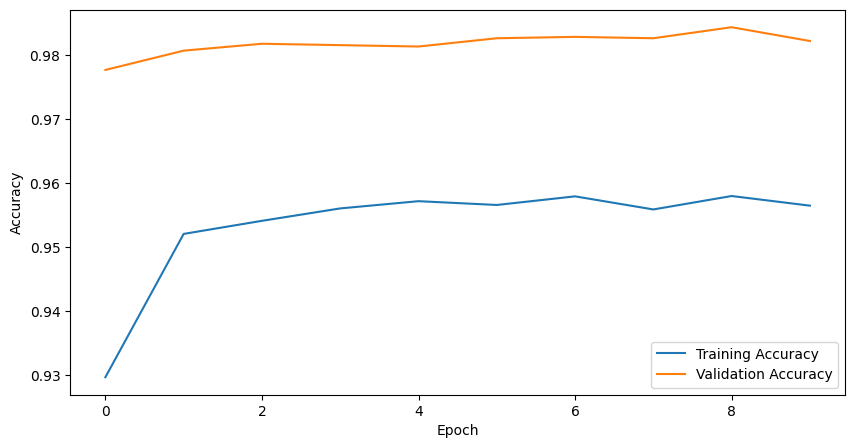

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Plot Loss Graph

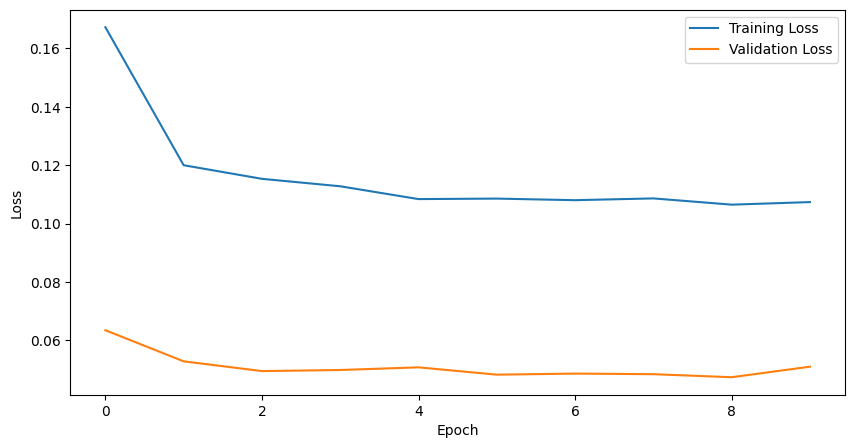

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Evaluate Validation Accuracy

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9822 - loss: 0.0509
Validation Accuracy: 0.9821581840515137


Save Weights

In [ ]:
model.save_weights(
    "cats_dogs_feature_extraction.weights.h5"
)